In [ ]:
import pandas as pd
import re
import spacy
import os
from PyPDF2 import PdfReader

# Setup
nlp = spacy.load("de_core_news_sm", disable=["parser", "ner"])
nlp.max_length = 2000000

def initial_process(text):
    if not isinstance(text, str) or len(text) < 10: return []
    doc = nlp(text)
    # Nur Nomen und Eigennamen extrahieren
    return [t.lemma_.lower() for t in doc if t.pos_ in ["NOUN", "PROPN"] and len(t.text) > 2]

base_path = "/Users/juliapusch/Documents/Hausarbeit_Data_Science/Corona_Urteile"
data = []

print(f"Lese PDFs ein...")
for root, dirs, files in os.walk(base_path):
    for filename in files:
        if filename.endswith(".pdf"):
            try:
                filepath = os.path.join(root, filename)
                reader = PdfReader(filepath)
                txt = "".join([p.extract_text() for p in reader.pages if p.extract_text()])
                
                if txt.strip():
                    # 1. Versuch: Jahr aus dem Dateipfad extrahieren
                    year_match = re.search(r"202[0-5]", filepath)
                    
                    if year_match:
                        year = int(year_match.group(0))
                    else:
                        # 2. Versuch: Jahr aus dem extrahierten Text suchen
                        text_year_match = re.search(r"202[0-5]", txt)
                        if text_year_match:
                            year = int(text_year_match.group(0))
                        else:
                            year = None

                    # Nur hinzufügen, wenn ein valides Jahr gefunden wurde
                    if year:
                        court = "BGH" if "BGH" in root.upper() else "EuGH"
                        data.append({
                            "text": txt, 
                            "datum": year, 
                            "gericht": court, 
                            "filename": filename
                        })
                    else:
                        print(f"⚠️ Übersprungen: Kein Datum für {filename} gefunden.")
                        
            except Exception as e:
                print(f"Fehler bei {filename}: {e}")

df = pd.DataFrame(data)
df['tokens_raw'] = df['text'].apply(initial_process)
df.to_pickle("urteile_cleaned.pkl")
print(f"✅ {len(df)} Urteile verarbeitet und in 'urteile_cleaned.pkl' gespeichert.")

Lese PDFs ein...
✅ 216 Urteile verarbeitet und in 'urteile_cleaned.pkl' gespeichert.


Starte Kohärenz-Analyse (Elbow-Method)...


/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' mod

Themenanzahl 4: Kohärenz = 0.6550


/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' mod

Themenanzahl 6: Kohärenz = 0.6975


...

Themenanzahl 10: Kohärenz = 0.7156


/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' mod

Themenanzahl 12: Kohärenz = 0.6849


/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' mod

Themenanzahl 14: Kohärenz = 0.6860


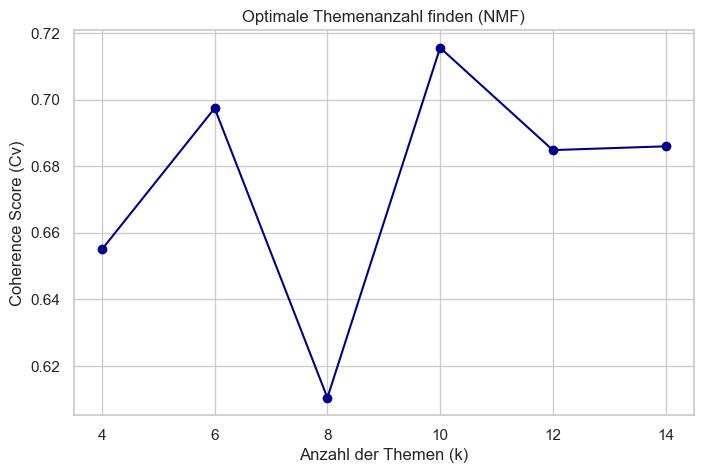


Trainiere finales NMF-Modell mit k=10...

--- Methodik ---


/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliapusch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' mod

Finaler NMF Kohärenz-Score (Cv): 0.7254

--- Themen-Cluster (Keywords) ---
Cluster 0: 0.037*"flug" + 0.035*"fluggast" + 0.020*"satz_fluggastrechtevo" + 0.020*"annullierung_reise" + 0.016*"luftfahrtunternehmen" + 0.015*"beförderung" + 0.014*"aida_cruises" + 0.013*"buchst_fluggastrechtevo" + 0.013*"annullierung" + 0.013*"annullierung_pauschalreise"
Cluster 1: 0.044*"inso" + 0.031*"insolvenzforderung" + 0.021*"eröffnung_insolvenzverfahren" + 0.019*"forderung" + 0.015*"insolvenzverfahren" + 0.014*"eröffnung" + 0.013*"insolvenzgläubiger" + 0.012*"flug" + 0.012*"umbuchung" + 0.011*"insolvenzverfahren_vermögen"
Cluster 2: 0.128*"dsgvo" + 0.054*"verarbeitung_datum" + 0.044*"verarbeitung" + 0.012*"verantwortliche_auftragsverarbeiter" + 0.008*"geldbuße" + 0.008*"rechtmäßigkeit_verarbeitung" + 0.008*"datum_verantwortliche" + 0.007*"app" + 0.007*"datenschutz" + 0.006*"rechtsgrundlage_verarbeitung"
Cluster 3: 0.020*"mieter" + 0.013*"miete" + 0.011*"störung_geschäftsgrundlage" + 0.011*"hochzeitsfeie

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from gensim import corpora, models
from gensim.models.nmf import Nmf
from gensim.models import Phrases, CoherenceModel
from gensim.models.phrases import Phraser

# 1. Daten laden
df = pd.read_pickle("urteile_cleaned.pkl")

# 2. Bigramme erstellen
phrases = Phrases(df['tokens_raw'], min_count=5, threshold=10)
bigram_mod = Phraser(phrases)
df['tokens'] = df['tokens_raw'].apply(lambda x: bigram_mod[x])

# 3. Stoppwortliste
custom_stops = {
    "streitfall", "sache", "sinn", "artikel", "absatz", "satz", "buchstabe", 
    "randnummer", "rn", "vorliegend", "hinsichtlich", "insbesondere", 
    "beziehungsweise", "sowie", "daher", "jedoch", "entscheidung", 
    "urteil", "beschluss", "berufungsgericht", "rechtsmittelführerin",
    "mitgliedstaat", "mitgliedstaaten",
    "datum", "februar", "märz", "april", "mai", "juni", "juli",
    "aktenzeichen", "online", "juris", "mwn", "beck", "njw", 
    "ebenda", "vgl", "ff", "abs", "nr",
    "satz_bgb", "sinn_651h", "sinn_art.3", "sache_berufungsgericht", 
    "teil_rechtsmittelgrund", "rede_maßnahme", "rede_beihilferegelung",
    "februar_c-584", "ryanair_gericht", "verantwortliche", "klagegrund",
    "schaden", "buchst_aeuv", "masseverbindlichkeit", "art.8_abs.", "republik_polen", "umsetzung_richtlinie",
    "art.260_abs.", "mitteilung", "kommunikation", "maßnahme_umsetzung", "kodex_für", "irland",
    "rra", "art.12_abs.", "richter_bundesgerichtshof", "stpo", "tat", "urteilsgründe", "bghst",
    "rra_kiwi", "eugh_urteil", "aufsichtsbehörde", "rt.4", "person_verarbeitung", "buchst_dsgvo", "zertifikat",
    "zweck_mittel", "art.14_abs.", "art.3_abs.", "masse", "beschluß", "verwalter", "c-658_c:2021:138", "datum_bereich",
    "kommission_spanien", "angeklagter", "stgb", "strafkammer", "einziehung", "staatsanwaltschaft", "landgericht_angeklagter",
    "tateinheit", "täter", "sachverständige", "gericht_rechtsfehler", "rechtsmittelgrund", "art.107_abs.",
    "ablauf_grund", "stellungnahme_frist", "kommission_irland", "faktor", "abschnitt_mitteilung", "verwaltungsvorschrift_richtlinie",
    "beurteilungsfehler", "beweis", "rechtsmittel", "str", "tatgericht", "sohn", "verarbeitungsvorgäng", "amt", "art.58_abs.",
    "art.4", "amtsgericht_beklagter", "grur_juris", "königreich_schweden", "begründungspflicht", "republik", "kind", "strafausspruch",
    "richter_hoffmann", "recht_freiheit", "insolvenzplan", "sinn_art.12", "verordnung_nr.", "schriftsatzfrist_januar", "gläubiger", "nstz_-rr", 
    "menge", "nstz", "arx_dr.", "verpflichtung_art.124", "tag_verkündung", "ekek", "grund_stellungnahme", "schwerekoeffizient",
    "schädiger", "art.108_abs.", "bestimmungsort", "art.7", "kodex_kommunikation", "gesetzgebungsverfahren", "dauer_verstoß",
    "dr._bacher", "vom_verbundene", "senatsurteil_bghz", "rückflug_lissabon", "nichtumsetzung_richtlinie", "klausel", "eingriff",
    "vom_rechtssache", "bundesrepublik_deutschland", "pückle_recht", "rechtsmittelführerin_gericht", "-ante-betrachtung_anhaltspunkt",
    "schweden", "marx_dr.", "ungarn", "antrag_schutz", "antragsteller", "buchst_verordnung", "märz_njw-rr", "bad_-württemberg",
    "rechtsfehler", "novation", "kommission_rumänien", "erwägungsgrund_beschluß", "bestimmungsort", "bestimmungsort_situation",
    "ereignis_schaden", "befristet_rahmen", "begründung_beschluß", "dr._deichfuß", "geschädigt", "oktober_mdr", "entscheidung_hof",
    "april_einklang", "hinblick_ziel", "bghz"
}

df['tokens'] = df['tokens'].apply(lambda x: [t for t in x if t not in custom_stops])

# 4. Dictionary & TF-IDF
dictionary = corpora.Dictionary(df['tokens'])
dictionary.filter_extremes(no_below=5, no_above=0.2)
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

tfidf = models.TfidfModel(corpus)
corpus_tfidf = tfidf[corpus]

# --- NEU: SCHLEIFE FÜR OPTIMALE THEMENANZAHL (ELBOW-METHOD) ---
print("Starte Kohärenz-Analyse (Elbow-Method)...")
def compute_nmf_coherence(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    for num_topics in range(start, limit, step):
        model = Nmf(corpus=corpus, id2word=dictionary, num_topics=num_topics, random_state=42, passes=20)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        score = coherencemodel.get_coherence()
        coherence_values.append(score)
        print(f"Themenanzahl {num_topics}: Kohärenz = {score:.4f}")
    return coherence_values

start, limit, step = 4, 15, 2
coherence_values = compute_nmf_coherence(dictionary, corpus_tfidf, df['tokens'], start, limit, step)

# Plotten der Kohärenzwerte für den Methodenteil
plt.figure(figsize=(8, 5))
plt.plot(range(start, limit, step), coherence_values, marker='o', color='darkblue')
plt.title("Optimale Themenanzahl finden (NMF)")
plt.xlabel("Anzahl der Themen (k)")
plt.ylabel("Coherence Score (Cv)")
plt.grid(True)
plt.show()

# 5. Finales NMF Training
print("\nTrainiere finales NMF-Modell mit k=10...")
nmf_model = Nmf(
    corpus=corpus_tfidf, 
    id2word=dictionary, 
    num_topics=10, 
    random_state=42, 
    passes=40
)

# 6. Finaler Kohärenz-Score & Ergebnisse
cm_nmf = CoherenceModel(model=nmf_model, texts=df['tokens'], dictionary=dictionary, coherence='c_v')
print(f"\n--- Methodik ---")
print(f"Finaler NMF Kohärenz-Score (Cv): {cm_nmf.get_coherence():.4f}")

print("\n--- Themen-Cluster (Keywords) ---")
for idx, topic in nmf_model.print_topics(num_words=10):
    print(f"Cluster {idx}: {topic}")

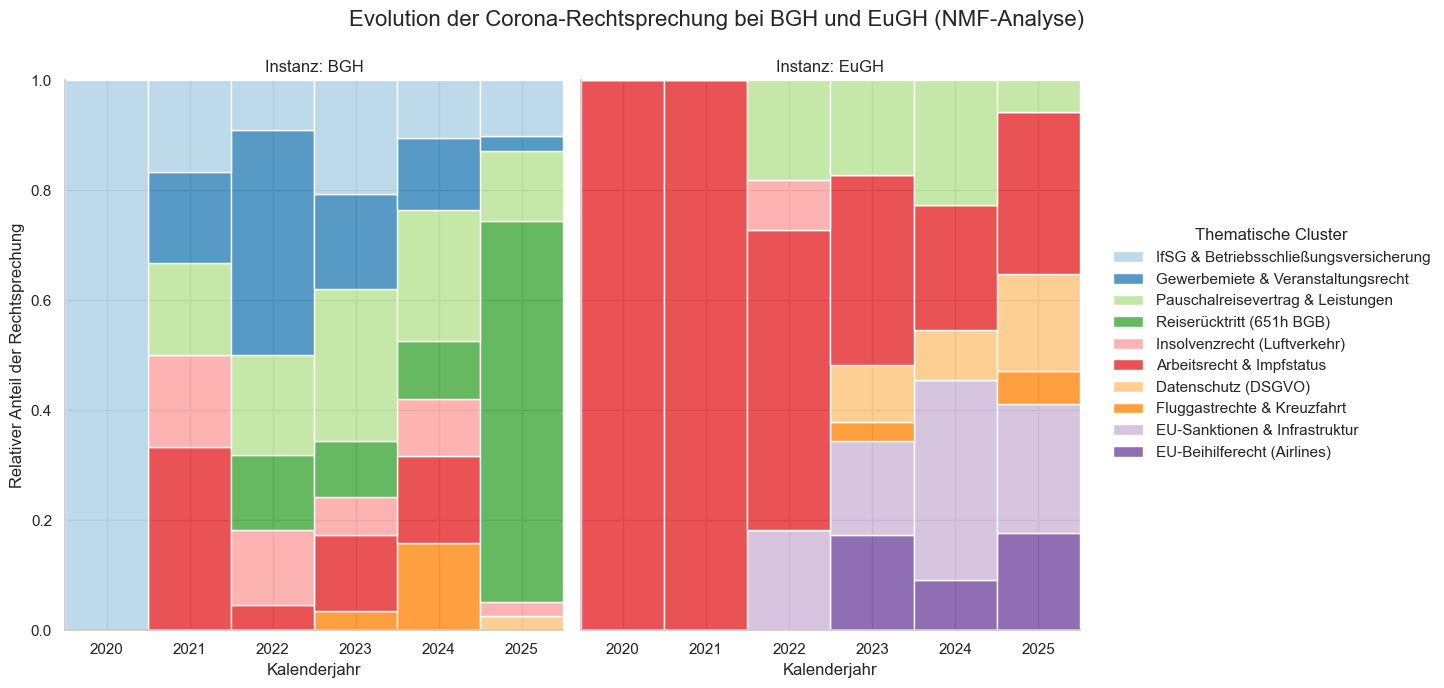

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Labels für die Hausarbeit
topic_labels = {
    0: "Fluggastrechte & Kreuzfahrt",
    1: "Insolvenzrecht (Luftverkehr)",
    2: "Datenschutz (DSGVO)",
    3: "Gewerbemiete & Veranstaltungsrecht",
    4: "EU-Beihilferecht (Airlines)",
    5: "EU-Sanktionen & Infrastruktur",
    6: "IfSG & Betriebsschließungsversicherung",
    7: "Reiserücktritt (651h BGB)",
    8: "Arbeitsrecht & Impfstatus",
    9: "Pauschalreisevertrag & Leistungen"
}

# Dominantes Thema pro Dokument extrahieren
def get_nmf_dominant_topic(model, bow):
    topics = model[bow]
    if not topics: return None
    return max(topics, key=lambda x: x[1])[0]

df['topic'] = [get_nmf_dominant_topic(nmf_model, dictionary.doc2bow(t)) for t in df['tokens']]
df['Rechtsgebiet'] = df['topic'].map(topic_labels)

# Grafik-Erstellung
sns.set_theme(style="whitegrid")
g = sns.displot(
    data=df, 
    x="datum", 
    hue="Rechtsgebiet", 
    col="gericht", 
    kind="hist", 
    multiple="fill", 
    discrete=True, 
    palette="Paired", 
    # Anpassung für DIN-A4 Hochformat:
    height=7,       # Erhöht die vertikale Ausdehnung
    aspect=0.8      # Macht die einzelnen Facetten schmaler, damit sie untereinander/nebeneinander besser passen
)

# Achsen und Titel beschriften (bleiben identisch)
g.set_axis_labels("Kalenderjahr", "Relativer Anteil der Rechtsprechung")
g.set_titles("Instanz: {col_name}")
g._legend.set_title("Thematische Cluster")

# Jahre auf X-Achse erzwingen (bleibt identisch)
for ax in g.axes.flat:
    ax.set_xticks(sorted(df['datum'].unique()))

plt.subplots_adjust(top=0.88) # Leicht angepasst, um dem höheren Format Rechnung zu tragen
g.fig.suptitle("Evolution der Corona-Rechtsprechung bei BGH und EuGH (NMF-Analyse)", fontsize=16)

# Finaler Export
plt.savefig("nmf_ergebnis_v.png", dpi=300, bbox_inches='tight')
plt.show()